#DETEKSI ANOMALI KUALITAS UDARA MENGGUNAKAN AUTO ENCODER

###Studi Kasus : Beijing PM2.5 Air Quality Dataset (2010–2014)

Nama Kelompok :
1. Nurul Firdasari Setyawan (103102400005)
2. Nadia Clearesta Shafira (1031024000007)
3. Fellycia Khoo (103102400010)
4. Eliza Sekar Arum (103102400071)


---
## 1. Latar Belakang & Urgensi

Polusi udara merupakan salah satu masalah lingkungan paling serius di dunia, terutama di kota-kota besar seperti **Beijing, China**. Partikel polutan berukuran sangat kecil yang dikenal sebagai **PM2.5** (Particulate Matter ≤ 2.5 mikrometer) terbukti berbahaya bagi kesehatan manusia karena dapat masuk langsung ke saluran pernapasan dan aliran darah, menyebabkan penyakit jantung, stroke, hingga kanker paru-paru.

### Mengapa ini penting?
- Beijing merupakan salah satu kota dengan tingkat polusi udara tertinggi di dunia, terutama pada musim dingin akibat penggunaan pemanas berbahan bakar batu bara
- Data PM2.5 bersifat time series dan multivariat — nilainya dipengaruhi oleh banyak faktor seperti suhu, tekanan udara, arah angin, dan curah hujan
- Deteksi dini terhadap kondisi polusi **ekstrem (anomali)** sangat penting agar pemerintah dan masyarakat dapat segera mengambil tindakan pencegahan




---
## 2. Gap Penelitian / Kebaruan (Novelty)

### Gap yang ditemukan:
Sebagian besar penelitian deteksi anomali kualitas udara menggunakan pendekatan **statistik sederhana** seperti z-score atau IQR yang hanya mempertimbangkan **satu variabel (univariat)** yaitu nilai PM2.5 saja. Pendekatan tersebut tidak mempertimbangkan hubungan antar variabel dan tidak mampu menangkap pola kompleks non-linear pada data.

### Kebaruan penelitian ini:
Penelitian ini menggunakan **Auto Encoder** — arsitektur *deep learning* — untuk melakukan deteksi anomali secara **multivariat**, yaitu mempertimbangkan **8 fitur sekaligus**:

1. PM2.5 = Konsentrasi polutan utama (µg/m³).
2. TEMP = Suhu udara (°C).
3. PRES = Tekanan udara (hPa).
4. DEWP = Titik embun (°C).
5. lws = Kecepatan angin kumulatif.
6. Is = Jam hujan salju kumulatif.
7. Ir = Jam hujan kumulatif.
8. cbwd = Arah angin (NW, NE, SE, cv)

Dengan mempertimbangkan semua fitur secara bersamaan, model dapat mendeteksi kondisi anomali yang **tidak terlihat** jika hanya melihat PM2.5 saja.


## 3. Tujuan Penelitian

1. Membangun model **Auto Encoder** menggunakan TensorFlow/Keras untuk mempelajari pola normal kualitas udara Beijing secara multivariat
2. Menggunakan **Reconstruction Error** sebagai indikator untuk mendeteksi kondisi udara yang tidak normal
3. Mendeteksi jam-jam dengan kondisi polusi udara **ekstrem/anomali** secara otomatis tanpa memerlukan label data
4. Menganalisis **pola temporal** anomali yang terdeteksi berdasarkan bulan dan tahun


## 4. Program Lengkap

### Step 1 — Import Library

Menyiapkan semua library yang dibutuhkan:
- `pandas` & `numpy` → manipulasi dan komputasi data
- `matplotlib` & `seaborn` → visualisasi grafik
- `sklearn` → preprocessing (normalisasi, encoding, split data)
- `tensorflow/keras` → membangun dan melatih model Auto Encoder

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.callbacks import EarlyStopping

import warnings
warnings.filterwarnings('ignore')

print("Versi TensorFlow:", tf.__version__)

Versi TensorFlow: 2.20.0


## Step 2 - Load Dataset

Membaca dataset Beijing PM2.5 dan melihat struktur data awal.

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving PRSA_data_2010.1.1-2014.12.31.csv to PRSA_data_2010.1.1-2014.12.31.csv


### Step 3 — Exploratory Data Analysis (EDA)

Sebelum membangun model, kita perlu memahami karakteristik data terlebih dahulu. EDA meliputi:
- Melihat tipe data dan jumlah baris/kolom
- Mengecek statistik deskriptif (rata-rata, min, max, dll)
- Mengecek missing values
- Visualisasi distribusi dan korelasi antar fitur


In [ ]:
df = pd.read_csv('PRSA_data_2010.1.1-2014.12.31.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43824 entries, 0 to 43823
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   No      43824 non-null  int64  
 1   year    43824 non-null  int64  
 2   month   43824 non-null  int64  
 3   day     43824 non-null  int64  
 4   hour    43824 non-null  int64  
 5   pm2.5   41757 non-null  float64
 6   DEWP    43824 non-null  int64  
 7   TEMP    43824 non-null  float64
 8   PRES    43824 non-null  float64
 9   cbwd    43824 non-null  object 
 10  Iws     43824 non-null  float64
 11  Is      43824 non-null  int64  
 12  Ir      43824 non-null  int64  
dtypes: float64(4), int64(8), object(1)
memory usage: 4.3+ MB


### Step 4 — Menampilkan Data Awal

Setelah dataset berhasil dimuat, langkah selanjutnya adalah menampilkan beberapa baris pertama menggunakan fungsi `df.head()`.

Tujuan dari tahap ini adalah:

- Melihat bentuk dan struktur data secara langsung.
- Memastikan dataset berhasil dibaca dengan benar.
- Mengenali atribut atau fitur yang tersedia.
- Memahami isi setiap kolom sebelum dilakukan proses analisis dan preprocessing.

Fungsi `df.head()` secara default menampilkan 5 baris pertama dari dataset.

In [ ]:
df.head()

,No,year,month,day,hour,pm2.5,DEWP,TEMP,PRES,cbwd,Iws,Is,Ir
0,1,2010,1,1,0,NaN,-21,-11.0,1021.0,NW,1.79,0,0
1,2,2010,1,1,1,NaN,-21,-12.0,1020.0,NW,4.92,0,0
2,3,2010,1,1,2,NaN,-21,-11.0,1019.0,NW,6.71,0,0
3,4,2010,1,1,3,NaN,-21,-14.0,1019.0,NW,9.84,0,0
4,5,2010,1,1,4,NaN,-20,-12.0,1018.0,NW,12.97,0,0


### Step 5 — Statistik Deskriptif Data

Statistik deskriptif digunakan untuk memberikan gambaran umum mengenai data numerik dalam dataset. Informasi yang ditampilkan meliputi:
- Jumlah data (count)
- Nilai rata-rata (mean)
- Standar deviasi (std)
- Nilai minimum dan maksimum
- Nilai kuartil (25%, 50%, dan 75%)

Hasil statistik ini membantu memahami karakteristik dan sebaran data sebelum dilakukan preprocessing.

In [ ]:
df.describe().round(2)

,No,year,month,day,hour,pm2.5,DEWP,TEMP,PRES,Iws,Is,Ir
count,43824.00,43824.00,43824.00,43824.00,43824.00,41757.00,43824.00,43824.00,43824.00,43824.00,43824.00,43824.00
mean,21912.50,2012.00,6.52,15.73,11.50,98.61,1.82,12.45,1016.45,23.89,0.05,0.19
std,12651.04,1.41,3.45,8.80,6.92,92.05,14.43,12.20,10.27,50.01,0.76,1.42
min,1.00,2010.00,1.00,1.00,0.00,0.00,-40.00,-19.00,991.00,0.45,0.00,0.00
25%,10956.75,2011.00,4.00,8.00,5.75,29.00,-10.00,2.00,1008.00,1.79,0.00,0.00
50%,21912.50,2012.00,7.00,16.00,11.50,72.00,2.00,14.00,1016.00,5.37,0.00,0.00
75%,32868.25,2013.00,10.00,23.00,17.25,137.00,15.00,23.00,1025.00,21.91,0.00,0.00
max,43824.00,2014.00,12.00,31.00,23.00,994.00,28.00,42.00,1046.00,585.60,27.00,36.00


### Step 6 — Pemeriksaan Missing Values

Tahap ini dilakukan untuk mengetahui apakah terdapat data yang hilang (*missing values*) pada setiap kolom dalam dataset.

Jumlah missing value pada masing-masing fitur ditampilkan sehingga dapat diketahui kolom mana yang memerlukan penanganan lebih lanjut sebelum proses preprocessing dan pelatihan model dilakukan.

In [ ]:
missing_values = df.isnull().sum()
print(missing_values)

No          0
year        0
month       0
day         0
hour        0
pm2.5    2067
DEWP        0
TEMP        0
PRES        0
cbwd        0
Iws         0
Is          0
Ir          0
dtype: int64


-Distribusi PM2.5
- Insight: distribusi sangat skewed ke kanan → ada banyak nilai ekstrem tinggi
- Nilai ekstrem inilah yang nanti akan terdeteksi sebagai anomali

# Penjelasan Grafik
- Histogram = distribusi PM2.5 sangat skewed ke kanan(tidak simetris). Artinya sebagian besar data punya PM2.5 rendah-sedang, tapi ada nilai ekstrem sangat tinggi di sisi kanan, inilah target anomali kita

### Step 7 — Visualisasi Distribusi PM2.5

Pada tahap ini dilakukan visualisasi distribusi nilai PM2.5 menggunakan histogram dan boxplot.

Visualisasi ini digunakan untuk:
- Melihat pola sebaran data PM2.5
- Mengidentifikasi kemencengan distribusi (skewness)
- Mendeteksi keberadaan nilai ekstrem (outlier)
- Memahami karakteristik data sebelum proses pemodelan

Histogram menunjukkan frekuensi kemunculan nilai PM2.5, sedangkan boxplot membantu memperlihatkan penyebaran data dan outlier secara lebih jelas.

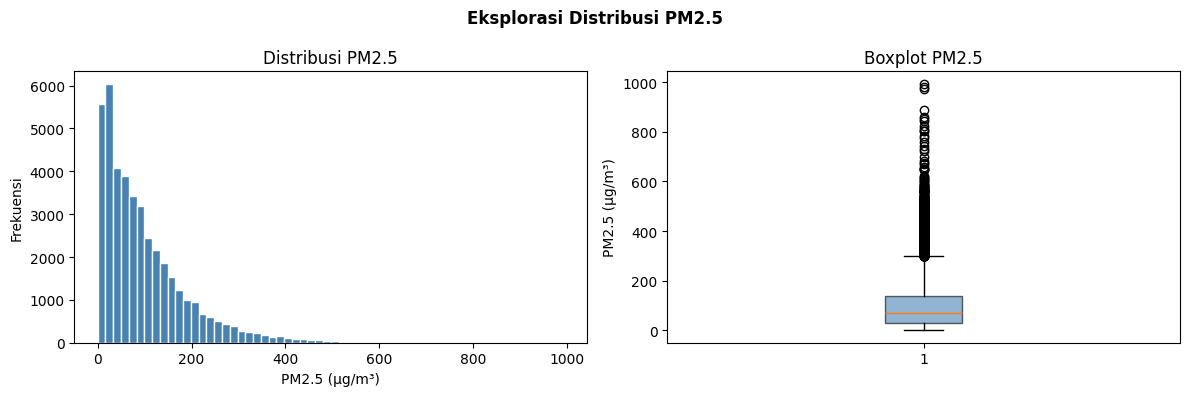

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['pm2.5'].dropna(), bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('Distribusi PM2.5')
axes[0].set_xlabel('PM2.5 (µg/m³)')
axes[0].set_ylabel('Frekuensi')

axes[1].boxplot(df['pm2.5'].dropna(), patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title('Boxplot PM2.5')
axes[1].set_ylabel('PM2.5 (µg/m³)')

plt.suptitle('Eksplorasi Distribusi PM2.5', fontweight='bold')
plt.tight_layout()
plt.show()


### Step 8 — Visualisasi Tren PM2.5

Grafik time series digunakan untuk melihat perubahan konsentrasi PM2.5 selama periode 2010–2014. Visualisasi ini membantu mengidentifikasi pola, fluktuasi, dan lonjakan nilai PM2.5 yang berpotensi menjadi anomali.

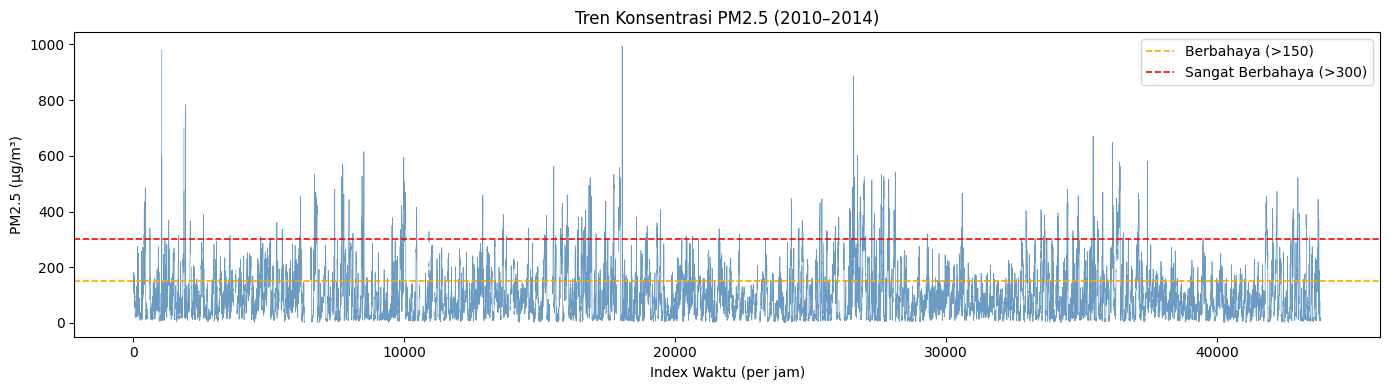

In [ ]:
plt.figure(figsize=(14, 4))
plt.plot(df['pm2.5'].values, color='steelblue', linewidth=0.5, alpha=0.8)
plt.axhline(y=150, color='orange', linestyle='--', linewidth=1.2, label='Berbahaya (>150)')
plt.axhline(y=300, color='red', linestyle='--', linewidth=1.2, label='Sangat Berbahaya (>300)')
plt.title('Tren Konsentrasi PM2.5 (2010–2014)')
plt.xlabel('Index Waktu (per jam)')
plt.ylabel('PM2.5 (µg/m³)')
plt.legend()
plt.tight_layout()
plt.show()


### Step 9 — Analisis Korelasi Antar Fitur

Heatmap korelasi digunakan untuk melihat hubungan antar fitur dalam dataset. Visualisasi ini membantu mengidentifikasi fitur yang memiliki korelasi positif maupun negatif terhadap variabel lainnya.

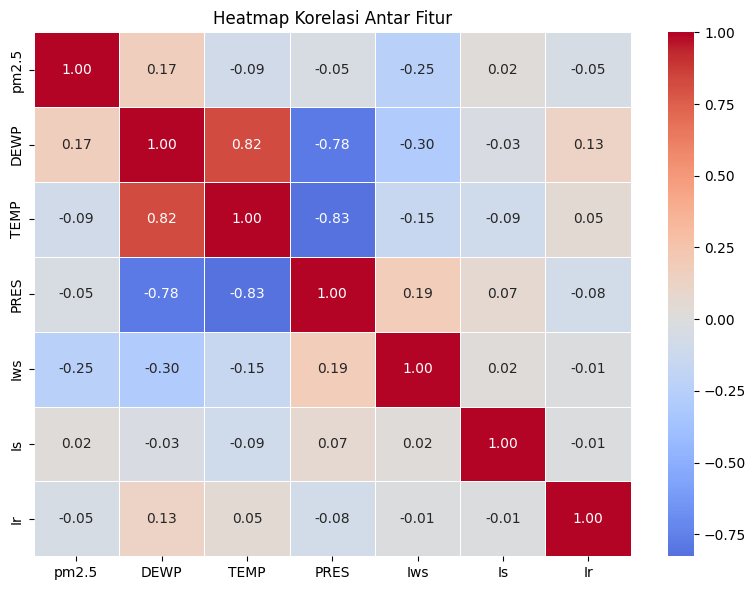

In [ ]:
plt.figure(figsize=(8, 6))
num_cols = ['pm2.5', 'DEWP', 'TEMP', 'PRES', 'Iws', 'Is', 'Ir']
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Heatmap Korelasi Antar Fitur')
plt.tight_layout()
plt.show()

### Step 10 — Penanganan Missing Values

Pada tahap ini dilakukan pengisian nilai yang hilang (*missing values*) pada kolom PM2.5 menggunakan metode *forward fill* dan *backward fill*. Setelah itu, dilakukan pengecekan kembali untuk memastikan tidak ada missing value yang tersisa dalam dataset.

In [ ]:
df['pm2.5'] = df['pm2.5'].fillna(method='ffill')
df['pm2.5'] = df['pm2.5'].fillna(method='bfill')

missing_values = df.isnull().sum()
print(missing_values)

No       0
year     0
month    0
day      0
hour     0
pm2.5    0
DEWP     0
TEMP     0
PRES     0
cbwd     0
Iws      0
Is       0
Ir       0
dtype: int64


#Preprocessing

### Step 11 — Encoding Data Kategorikal

Pada tahap ini, kolom `cbwd` yang berisi data kategorikal (arah angin) diubah menjadi bentuk numerik menggunakan metode *Label Encoding*. Hasil encoding digunakan agar data dapat diproses oleh model machine learning.

In [ ]:
le = LabelEncoder()
df['cbwd_enc'] = le.fit_transform(df['cbwd'])

print("Mapping arah angin:")
for i, label in enumerate(le.classes_):
    print(f"  {label} → {i}")


Mapping arah angin:
  NE → 0
  NW → 1
  SE → 2
  cv → 3


### Step 12 — Normalisasi Data

Pada tahap ini dipilih fitur yang akan digunakan dalam proses pemodelan. Selanjutnya, data dinormalisasi menggunakan *MinMaxScaler* sehingga seluruh nilai berada pada rentang 0–1 agar proses pelatihan model menjadi lebih optimal.

In [ ]:
features = ['pm2.5', 'DEWP', 'TEMP', 'PRES', 'Iws', 'Is', 'Ir', 'cbwd_enc']
X = df[features].values

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

print("Shape data:", X_scaled.shape)
print("Rentang nilai setelah normalisasi:")
print(f"Min: {X_scaled.min():.2f} | Max: {X_scaled.max():.2f}")

Shape data: (43824, 8)
Rentang nilai setelah normalisasi:
Min: 0.00 | Max: 1.00


### Step 13 — Pembagian Data Training dan Testing

Data yang telah dinormalisasi dibagi menjadi data training dan data testing menggunakan fungsi `train_test_split()`. Pada proses ini digunakan parameter `test_size=0.2`, yang berarti 20% data digunakan sebagai data testing, sedangkan 80% sisanya digunakan sebagai data training.

In [ ]:
X_train, X_test = train_test_split(X_scaled, test_size=0.2, random_state=42)

print(f"Data training : {X_train.shape[0]:,} baris")
print(f"Data testing  : {X_test.shape[0]:,} baris")
print(f"Jumlah fitur  : {X_train.shape[1]}")

Data training : 35,059 baris
Data testing  : 8,765 baris
Jumlah fitur  : 8


### Step 14 — Membangun Arsitektur Auto Encoder

Pada tahap ini dibuat model Auto Encoder yang terdiri dari bagian encoder, latent space, dan decoder. Model digunakan untuk mempelajari pola data normal dengan cara merekonstruksi kembali data input sehingga dapat digunakan untuk mendeteksi anomali berdasarkan nilai reconstruction error.

In [ ]:
input_dim = X_train.shape[1]

inputs = Input(shape=(input_dim,), name='Input')

x = Dense(6, activation='relu', name='Encoder_1')(inputs)
x = Dense(4, activation='relu', name='Encoder_2')(x)
latent = Dense(3, activation='relu', name='LatentSpace')(x)

x = Dense(4, activation='relu', name='Decoder_1')(latent)
x = Dense(6, activation='relu', name='Decoder_2')(x)
outputs = Dense(input_dim, activation='sigmoid', name='Output')(x)

autoencoder = Model(inputs=inputs, outputs=outputs, name='AutoEncoder')
autoencoder.compile(optimizer='adam', loss='mse')

autoencoder.summary()

Model: "AutoEncoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input (InputLayer)              │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Encoder_1 (Dense)               │ (None, 6)              │            54 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Encoder_2 (Dense)               │ (None, 4)              │            28 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ LatentSpace (Dense)             │ (None, 3)              │            15 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Decoder_1 (Dense)               │ (None, 4)              │            16 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Decoder_2 (Dense)               │ (None, 6)              │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 8)              │            56 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 199 (796.00 B)

 Trainable params: 199 (796.00 B)

 Non-trainable params: 0 (0.00 B)

### Step 15 — Training Model Auto Encoder

Pada tahap ini model Auto Encoder dilatih menggunakan data training yang telah disiapkan sebelumnya. Selain itu, digunakan fitur *Early Stopping* untuk menghentikan proses training secara otomatis ketika performa model pada data validasi sudah tidak mengalami peningkatan. Hal ini dilakukan agar model dapat belajar dengan baik tanpa melakukan training yang berlebihan.

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

history = autoencoder.fit(
    X_train, X_train,
    epochs=100,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
494/494 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0588 - val_loss: 0.0287
Epoch 2/100
494/494 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0221 - val_loss: 0.0149
Epoch 3/100
494/494 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0103 - val_loss: 0.0086
Epoch 4/100
494/494 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0077 - val_loss: 0.0070
Epoch 5/100
494/494 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0066 - val_loss: 0.0063
Epoch 6/100
494/494 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0061 - val_loss: 0.0059
Epoch 7/100
494/494 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0058 - val_loss: 0.0057
Epoch 8/100
494/494 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0056 - val_loss: 0.0055
Epoch 9/100
494/494 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0055 - val_loss: 0.0054
Epoch 10/100
494/494 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0054 - val_loss: 0.0053
Epoch 11/100
494/494 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0053 - val_loss: 0.0053
Epoch 12/100
494/494 ━━━━━━━━━━━━━━━━━━━━

### Step 16 — Visualisasi Hasil Training Model

Setelah proses training selesai, dilakukan visualisasi nilai *training loss* dan *validation loss* pada setiap epoch. Grafik ini digunakan untuk melihat perkembangan proses pembelajaran model.

Berdasarkan grafik, nilai *loss* menurun dengan cepat pada awal training dan kemudian stabil. Selain itu, kurva *training loss* dan *validation loss* terlihat berdekatan, yang menunjukkan bahwa model mampu mempelajari pola data dengan baik dan memberikan performa yang konsisten pada data validasi.

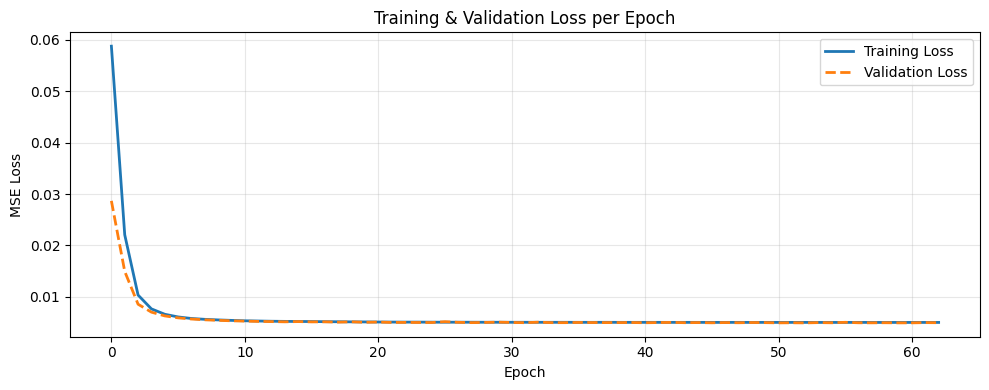

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Training Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2, linestyle='--')
plt.title('Training & Validation Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Step 17 — Menghitung Reconstruction Error

Reconstruction Error bisa di simpulkan seperti ukuran seberapa buruk model meekonstruksi data.

Digunakan sebagai indikator anomali. Karena model hanya dilatih dari data normal, ketika menemukan data yang tidak normal, model tidak bisa merekonstruksi dengan baik sehingga error-nya besar. Data dengan RE melebihi threshold diklasifikasikan sebagai anomali.

Tujuan dari Reconstrction Error pada penelitian kita yaitu dipakai untuk mendekteksi anomali tanpa butuh label apapun.

Model hanya belajar dari data NORMAL
        ↓
Ketemu data NORMAL   → bisa rekonstruksi dengan baik → RE kecil
Ketemu data ANOMALI  → gagal rekonstruksi            → RE besar
        ↓
RE besar = sinyal bahwa data tersebut TIDAK NORMAL

Langkah-langkah Reconstruction Error:
1. X_pred = autoencoder.predict(X_scaled)
Semua data dimasukkan ke model dan model mengeluarkan versi rekonstruksinya
Data asli (X_scaled) → [AUTO ENCODER] → Hasil rekonstruksi (X_pred)

2. Hitung selisih asli vs rekonstruksi
X_scaled - X_pred
contoh untuk 1 data dengan 3 fitur
Asli        : [0.8,  0.3,  0.5]
Rekonstruksi: [0.79, 0.31, 0.48]
Selisih     : [0.01, 0.01, 0.02]  ← kecil = normal

Asli        : [0.95, 0.1,  0.9]
Rekonstruksi: [0.4,  0.6,  0.3]
Selisih     : [0.55, 0.5,  0.6]  ← besar = anomali

3. Kuadratkan selisihnya
np.power(X_scaled - X_pred, 2)
dikuadratkan supaya nilai negatif menjadi positif

4. Rata-rata per baris
reconstruction_error = np.mean(np.power(X_scaled - X_pred, 2), axis=1)


In [ ]:
X_pred = autoencoder.predict(X_scaled)

reconstruction_error = np.mean(np.power(X_scaled - X_pred, 2), axis=1)

print("Statistik Reconstruction Error:")
print(f"Rata-rata (μ) : {reconstruction_error.mean():.6f}")
print(f"Std dev (σ)   : {reconstruction_error.std():.6f}")
print(f"Min           : {reconstruction_error.min():.6f}")
print(f"Max           : {reconstruction_error.max():.6f}")

1370/1370 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
Statistik Reconstruction Error:
Rata-rata (μ) : 0.005016
Std dev (σ)   : 0.006535
Min           : 0.000039
Max           : 0.133868


### Step 18 — Menentukan Threshold dan Mendeteksi Anomali

Pada tahap ini ditentukan nilai *threshold* untuk membedakan data normal dan data anomali. Threshold dihitung menggunakan rumus μ + 2σ, yaitu rata-rata (*mean*) ditambah dua kali standar deviasi dari *reconstruction error*.

Data dengan nilai *reconstruction error* melebihi threshold akan dikategorikan sebagai anomali, sedangkan data yang berada di bawah threshold dianggap sebagai data normal.

In [ ]:
threshold = reconstruction_error.mean() + 2 * reconstruction_error.std()
print(f"Threshold anomali = μ + 2σ = {threshold:.6f}")

anomaly = reconstruction_error > threshold

print(f"\nTotal data    : {len(anomaly):,}")
print(f"Data normal   : {(~anomaly).sum():,} ({(~anomaly).mean()*100:.1f}%)")
print(f"Data anomali  : {anomaly.sum():,} ({anomaly.mean()*100:.1f}%)")

Threshold anomali = μ + 2σ = 0.018086

Total data    : 43,824
Data normal   : 42,293 (96.5%)
Data anomali  : 1,531 (3.5%)


### Step 19 — Visualisasi Reconstruction Error

Pada tahap ini dilakukan visualisasi distribusi nilai *reconstruction error* menggunakan histogram. Garis merah menunjukkan nilai *threshold* yang digunakan sebagai batas antara data normal dan data anomali.

Data yang memiliki *reconstruction error* melebihi threshold akan dikategorikan sebagai anomali, sedangkan data yang berada di bawah threshold dianggap sebagai data normal.

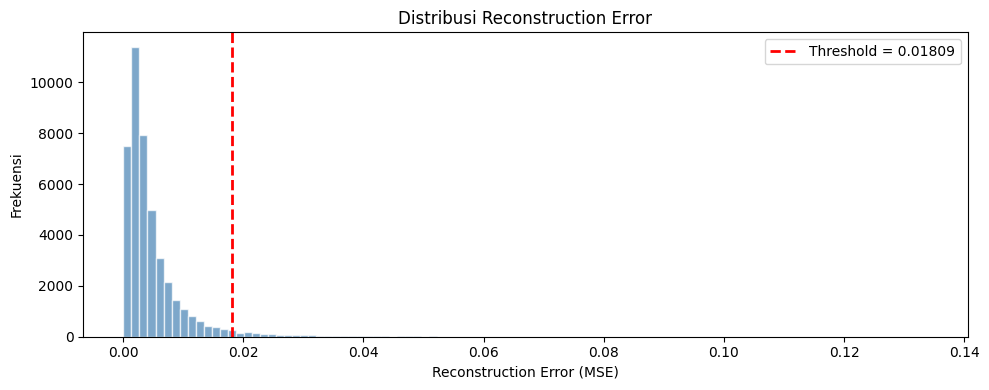

In [ ]:
plt.figure(figsize=(10, 4))
plt.hist(reconstruction_error, bins=100, color='steelblue', alpha=0.7, edgecolor='white')
plt.axvline(x=threshold, color='red', linestyle='--', linewidth=2,
            label=f'Threshold = {threshold:.5f}')
plt.title('Distribusi Reconstruction Error')
plt.xlabel('Reconstruction Error (MSE)')
plt.ylabel('Frekuensi')
plt.legend()
plt.tight_layout()
plt.show()

### Step 20 — Visualisasi Hasil Deteksi Anomali

Pada tahap ini hasil deteksi anomali divisualisasikan pada data PM2.5. Titik berwarna merah menunjukkan data yang terdeteksi sebagai anomali berdasarkan nilai *reconstruction error* yang melebihi threshold, sedangkan garis biru menunjukkan data PM2.5 secara keseluruhan.

Visualisasi ini membantu melihat posisi dan pola kemunculan anomali pada data kualitas udara selama periode pengamatan.

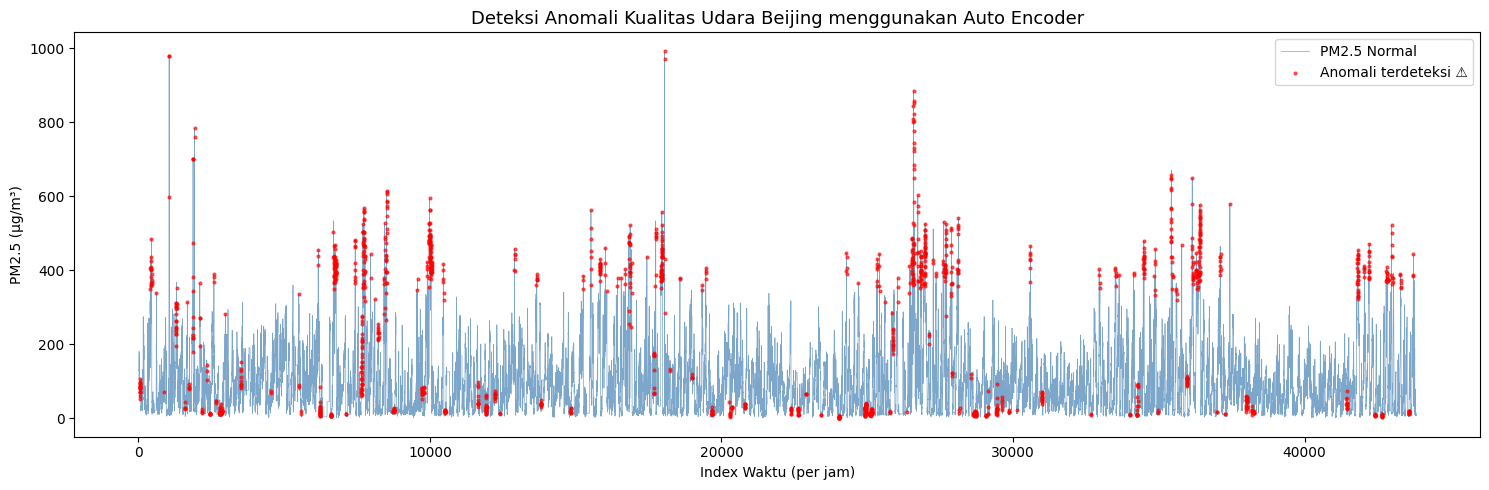

In [ ]:
df_result = df.copy()
df_result['reconstruction_error'] = reconstruction_error
df_result['anomaly'] = anomaly

plt.figure(figsize=(15, 5))
plt.plot(df_result['pm2.5'].values, color='steelblue',
         linewidth=0.5, alpha=0.7, label='PM2.5 Normal')

idx_anomali = df_result[df_result['anomaly']].index
plt.scatter(idx_anomali, df_result.loc[idx_anomali, 'pm2.5'],
            color='red', s=4, alpha=0.6, label='Anomali terdeteksi ⚠️', zorder=5)

plt.title('Deteksi Anomali Kualitas Udara Beijing menggunakan Auto Encoder', fontsize=13)
plt.xlabel('Index Waktu (per jam)')
plt.ylabel('PM2.5 (µg/m³)')
plt.legend()
plt.tight_layout()
plt.show()

### Step 21 — Visualisasi Reconstruction Error terhadap Threshold

Pada tahap ini dilakukan visualisasi nilai *reconstruction error* dan *threshold* untuk melihat secara lebih jelas data yang terdeteksi sebagai anomali. Area berwarna merah menunjukkan data yang memiliki *reconstruction error* melebihi threshold sehingga dikategorikan sebagai anomali.

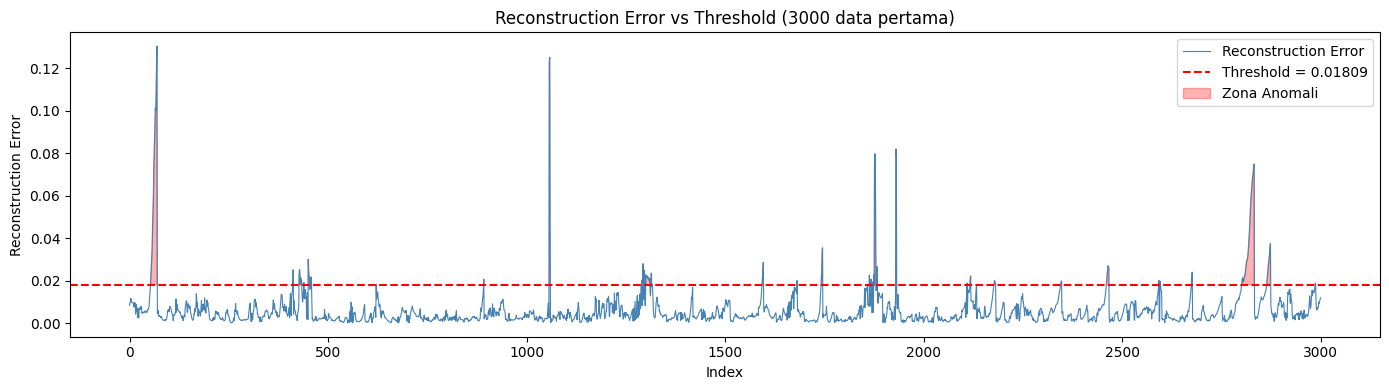

In [ ]:
plt.figure(figsize=(14, 4))
n = 3000
plt.plot(range(n), reconstruction_error[:n], color='steelblue', linewidth=0.8, label='Reconstruction Error')
plt.axhline(y=threshold, color='red', linestyle='--', linewidth=1.5,
            label=f'Threshold = {threshold:.5f}')
plt.fill_between(range(n),
                 reconstruction_error[:n], threshold,
                 where=reconstruction_error[:n] > threshold,
                 color='red', alpha=0.3, label='Zona Anomali')
plt.title('Reconstruction Error vs Threshold (3000 data pertama)')
plt.xlabel('Index')
plt.ylabel('Reconstruction Error')
plt.legend()
plt.tight_layout()
plt.show()

### Step 22 — Analisis Karakteristik Anomali

Pada tahap ini dilakukan analisis lebih lanjut terhadap hasil deteksi anomali. Visualisasi pertama membandingkan distribusi nilai PM2.5 antara data normal dan data anomali menggunakan boxplot. Visualisasi kedua menunjukkan jumlah anomali yang terdeteksi pada setiap bulan selama periode pengamatan.

Analisis ini membantu memahami karakteristik anomali serta melihat pola kemunculannya dari waktu ke waktu.

<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

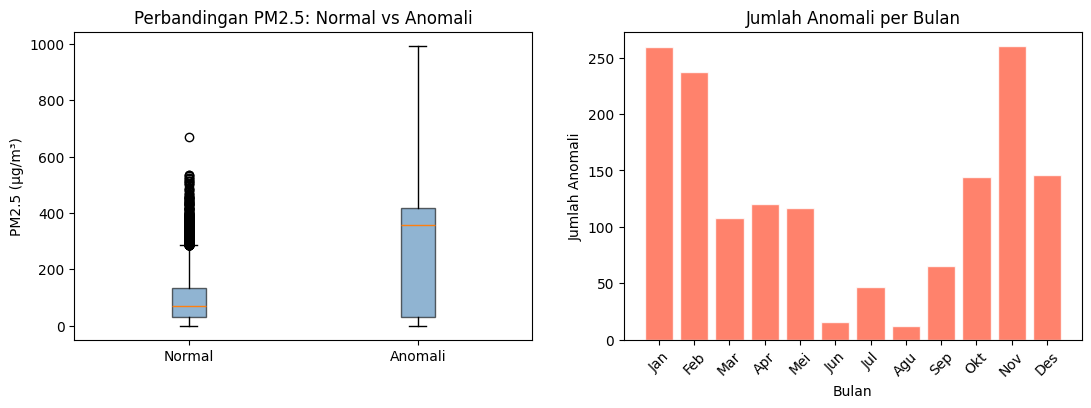

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].boxplot(
    [df_result[~df_result['anomaly']]['pm2.5'].dropna().values,
     df_result[df_result['anomaly']]['pm2.5'].dropna().values],
    labels=['Normal', 'Anomali'],
    patch_artist=True,
    boxprops=dict(facecolor='steelblue', alpha=0.6)
)
axes[0].set_title('Perbandingan PM2.5: Normal vs Anomali')
axes[0].set_ylabel('PM2.5 (µg/m³)')

anomali_per_bulan = df_result[df_result['anomaly']].groupby('month').size()
axes[1].bar(anomali_per_bulan.index, anomali_per_bulan.values,
            color='tomato', alpha=0.8, edgecolor='white')
axes[1].set_title('Jumlah Anomali per Bulan')
axes[1].set_xlabel('Bulan')
axes[1].set_ylabel('Jumlah Anomali')
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(['Jan','Feb','Mar','Apr','Mei','Jun',
                          'Jul','Agu','Sep','Okt','Nov','Des'], rotation=45)
plt.tight_layout

### Step 23 — Perbandingan Statistik PM2.5 pada Data Normal dan Anomali

Pada tahap ini dilakukan perbandingan statistik PM2.5 antara data normal dan data yang terdeteksi sebagai anomali. Analisis dilakukan menggunakan statistik deskriptif seperti rata-rata, nilai minimum, maksimum, dan kuartil untuk melihat perbedaan karakteristik kedua kelompok data.

In [ ]:
print("Statistik PM2.5: Normal vs Anomali")

normal_pm = df_result[~df_result['anomaly']]['pm2.5']
anomali_pm = df_result[df_result['anomaly']]['pm2.5']

ringkasan = pd.DataFrame({
    'Normal': normal_pm.describe(),
    'Anomali': anomali_pm.describe()
}).round(2)

print(ringkasan)

print(f"\nRata-rata PM2.5 data normal  : {normal_pm.mean():.2f} µg/m³")
print(f"Rata-rata PM2.5 data anomali : {anomali_pm.mean():.2f} µg/m³")
print(f"Selisih rata-rata            : {anomali_pm.mean() - normal_pm.mean():.2f} µg/m³")

Statistik PM2.5: Normal vs Anomali
         Normal  Anomali
count  42293.00  1531.00
mean      91.91   260.48
std       78.32   205.29
min        0.00     0.00
25%       29.00    29.00
50%       71.00   356.00
75%      132.00   419.00
max      671.00   994.00

Rata-rata PM2.5 data normal  : 91.91 µg/m³
Rata-rata PM2.5 data anomali : 260.48 µg/m³
Selisih rata-rata            : 168.57 µg/m³


### Step 24 — Analisis Sebaran Anomali Berdasarkan Waktu

Pada tahap ini dilakukan analisis jumlah anomali berdasarkan tahun dan bulan. Analisis ini bertujuan untuk melihat pola kemunculan anomali selama periode pengamatan serta mengetahui periode waktu yang memiliki jumlah anomali paling banyak.

In [ ]:
print("Jumlah Anomali per Tahun")
print(df_result[df_result['anomaly']].groupby('year').size())

print("\nBulan dengan Anomali Terbanyak")
bulan_map = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'Mei',6:'Jun',
             7:'Jul',8:'Agu',9:'Sep',10:'Okt',11:'Nov',12:'Des'}
anomali_bulan = df_result[df_result['anomaly']].groupby('month').size()
anomali_bulan.index = anomali_bulan.index.map(bulan_map)
print(anomali_bulan.sort_values(ascending=False).head(5))

Jumlah Anomali per Tahun
year
2010    398
2011    255
2012    271
2013    333
2014    274
dtype: int64

Bulan dengan Anomali Terbanyak
month
Nov    260
Jan    259
Feb    237
Des    146
Okt    144
dtype: int64


#Perbandingan Before After Rekontruksi

Bagian ini menampilkan grafik tambahan untuk memperkaya analisis, termasuk perbandingan data asli vs hasil rekonstruksi oleh Auto Encoder.

- Catatan: nilai sudah ternormalisasi (0-1) karena kita pakai MinMaxScaler
-  Kalau garis merah jauh dari biru = rekonstruksi jelek = kemungkinan anomali

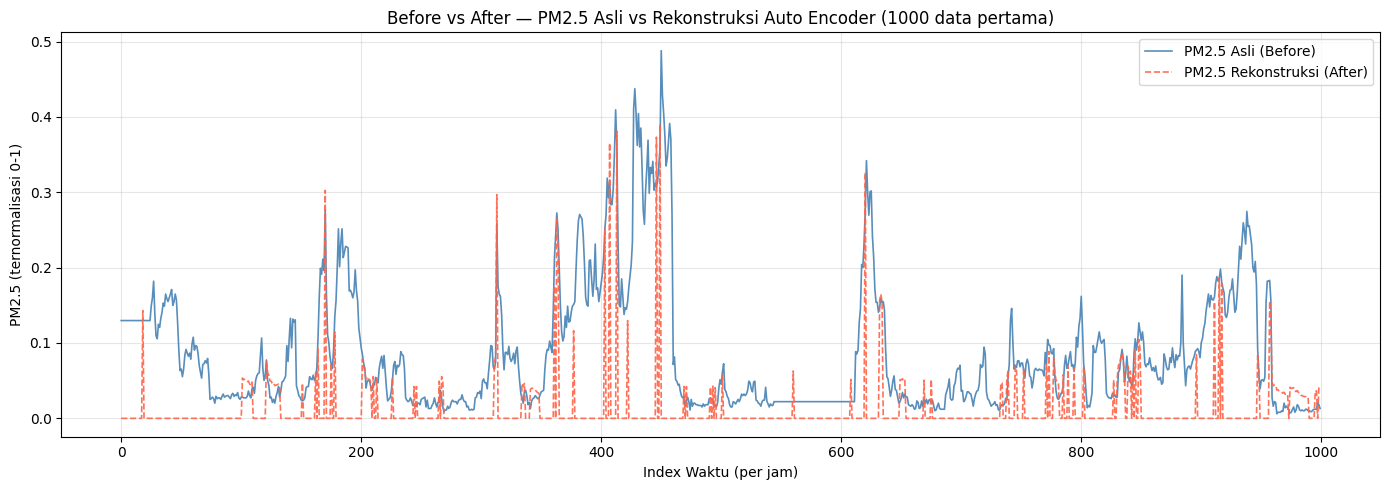

In [ ]:
pm25_asli = X_scaled[:, 0]
pm25_rekonstruksi = X_pred[:, 0]

# Tampilkan 1000 data pertama agar lebih jelas
n_tampil = 1000

plt.figure(figsize=(14, 5))
plt.plot(range(n_tampil), pm25_asli[:n_tampil],
         color='steelblue', linewidth=1.2, label='PM2.5 Asli (Before)', alpha=0.9)
plt.plot(range(n_tampil), pm25_rekonstruksi[:n_tampil],
         color='tomato', linewidth=1.2, linestyle='--', label='PM2.5 Rekonstruksi (After)', alpha=0.9)
plt.title('Before vs After — PM2.5 Asli vs Rekonstruksi Auto Encoder (1000 data pertama)', fontsize=12)
plt.xlabel('Index Waktu (per jam)')
plt.ylabel('PM2.5 (ternormalisasi 0-1)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#Scatter Plot — Nilai Asli vs Rekonstruksi
Scatter plot ini menunjukkan seberapa akurat Auto Encoder merekonstruksi data.

- Titik yang dekat garis diagonal = rekonstruksi akurat (normal)
- Titik yang jauh dari garis diagonal = rekonstruksi buruk (anomali)

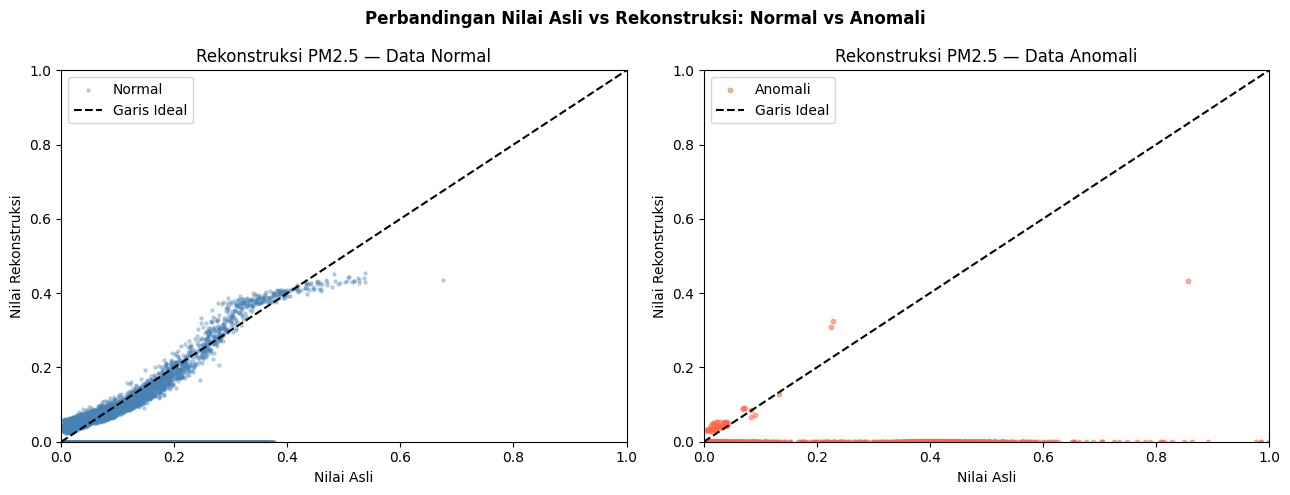

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter: data normal
normal_idx = np.where(~anomaly)[0]
axes[0].scatter(X_scaled[normal_idx, 0], X_pred[normal_idx, 0],
                alpha=0.3, s=5, color='steelblue', label='Normal')
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Garis Ideal')
axes[0].set_title('Rekonstruksi PM2.5 — Data Normal')
axes[0].set_xlabel('Nilai Asli')
axes[0].set_ylabel('Nilai Rekonstruksi')
axes[0].legend()
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1)

# Scatter: data anomali
anomaly_idx = np.where(anomaly)[0]
axes[1].scatter(X_scaled[anomaly_idx, 0], X_pred[anomaly_idx, 0],
                alpha=0.5, s=10, color='tomato', label='Anomali')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Garis Ideal')
axes[1].set_title('Rekonstruksi PM2.5 — Data Anomali')
axes[1].set_xlabel('Nilai Asli')
axes[1].set_ylabel('Nilai Rekonstruksi')
axes[1].legend()
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1)

plt.suptitle('Perbandingan Nilai Asli vs Rekonstruksi: Normal vs Anomali', fontweight='bold')
plt.tight_layout()
plt.show()

#Before vs After — Contoh Data Normal vs Anomali
Visualisasi ini menampilkan perbandingan langsung nilai semua fitur antara data asli dan rekonstruksi, untuk 1 contoh data normal dan 1 contoh data anomali.
 - Data normal → bar biru dan biru muda hampir sama tingginya = rekonstruksi bagus
 - Data anomali → bar merah dan oranye muda beda jauh = rekonstruksi jelek


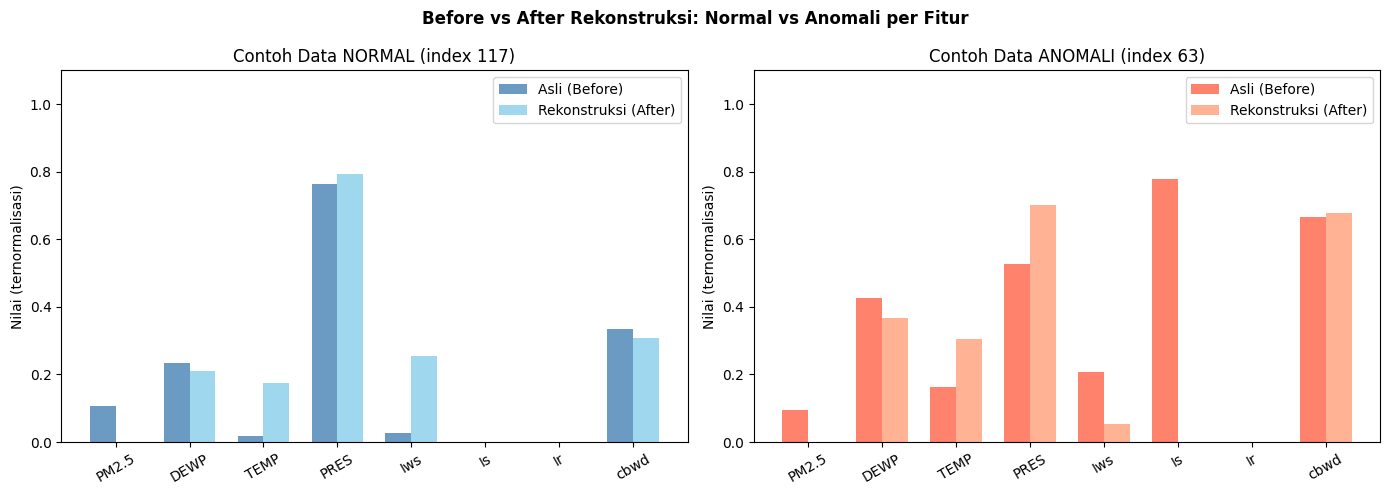

In [ ]:
fitur_label = ['PM2.5', 'DEWP', 'TEMP', 'PRES', 'Iws', 'Is', 'Ir', 'cbwd']
x_pos = np.arange(len(fitur_label))
lebar = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Contoh data normal (ambil 1 sampel dari data normal)
idx_normal_contoh = normal_idx[100]
axes[0].bar(x_pos - lebar/2, X_scaled[idx_normal_contoh],
            lebar, label='Asli (Before)', color='steelblue', alpha=0.8)
axes[0].bar(x_pos + lebar/2, X_pred[idx_normal_contoh],
            lebar, label='Rekonstruksi (After)', color='skyblue', alpha=0.8)
axes[0].set_title(f'Contoh Data NORMAL (index {idx_normal_contoh})')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(fitur_label, rotation=30)
axes[0].set_ylabel('Nilai (ternormalisasi)')
axes[0].legend()
axes[0].set_ylim(0, 1.1)

# Contoh data anomali (ambil 1 sampel dari data anomali)
idx_anomali_contoh = anomaly_idx[10]
axes[1].bar(x_pos - lebar/2, X_scaled[idx_anomali_contoh],
            lebar, label='Asli (Before)', color='tomato', alpha=0.8)
axes[1].bar(x_pos + lebar/2, X_pred[idx_anomali_contoh],
            lebar, label='Rekonstruksi (After)', color='lightsalmon', alpha=0.8)
axes[1].set_title(f'Contoh Data ANOMALI (index {idx_anomali_contoh})')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(fitur_label, rotation=30)
axes[1].set_ylabel('Nilai (ternormalisasi)')
axes[1].legend()
axes[1].set_ylim(0, 1.1)

plt.suptitle('Before vs After Rekonstruksi: Normal vs Anomali per Fitur', fontweight='bold')
plt.tight_layout()
plt.show()

#Heatmap Anomali per Bulan per Tahun
Heatmap ini menunjukkan distribusi anomali secara lebih detail — berapa banyak anomali terjadi di setiap bulan pada setiap tahun.
 - Warna lebih gelap = anomali lebih banyak
 -  Dari heatmap ini terlihat bulan dan tahun mana yang paling banyak anomali

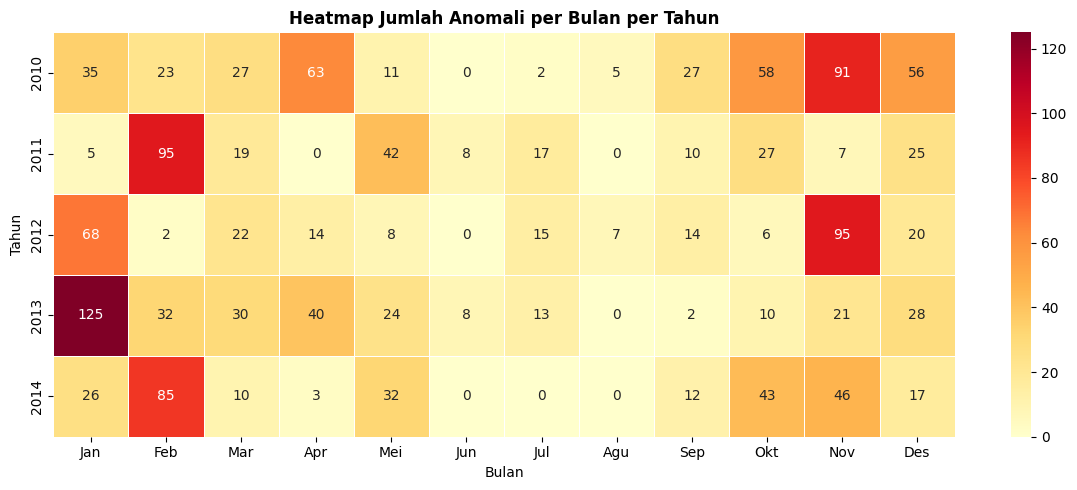

In [ ]:
pivot = df_result[df_result['anomaly']].groupby(['year', 'month']).size().unstack(fill_value=0)

plt.figure(figsize=(12, 5))
sns.heatmap(pivot, annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=['Jan','Feb','Mar','Apr','Mei','Jun','Jul','Agu','Sep','Okt','Nov','Des'],
            linewidths=0.5)
plt.title('Heatmap Jumlah Anomali per Bulan per Tahun', fontweight='bold')
plt.xlabel('Bulan')
plt.ylabel('Tahun')
plt.tight_layout()
plt.show()

#Rata-rata Reconstruction Error per Tahun
Grafik ini menunjukkan apakah kualitas udara Beijing membaik atau memburuk dari tahun ke tahun berdasarkan rata-rata reconstruction error.

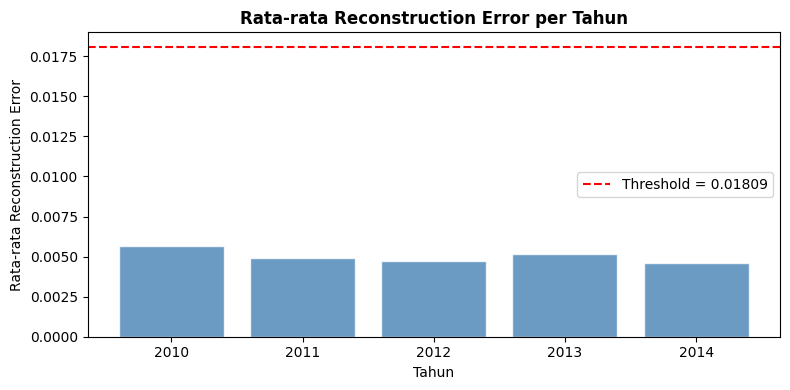

In [ ]:
re_per_tahun = df_result.groupby('year')['reconstruction_error'].mean()

plt.figure(figsize=(8, 4))
plt.bar(re_per_tahun.index, re_per_tahun.values,
        color='steelblue', alpha=0.8, edgecolor='white')
plt.axhline(y=threshold, color='red', linestyle='--', linewidth=1.5,
            label=f'Threshold = {threshold:.5f}')
plt.title('Rata-rata Reconstruction Error per Tahun', fontweight='bold')
plt.xlabel('Tahun')
plt.ylabel('Rata-rata Reconstruction Error')
plt.legend()
plt.tight_layout()
plt.show()

# Analisis Hasil

Berdasarkan hasil pelatihan Autoencoder, model mampu mempelajari pola normal kualitas udara pada dataset Beijing PM2.5. Data yang memiliki reconstruction error tinggi dikategorikan sebagai anomali.

Anomali yang terdeteksi umumnya muncul pada periode dengan konsentrasi PM2.5 yang sangat tinggi dibandingkan kondisi normal. Hal ini menunjukkan bahwa Autoencoder dapat digunakan untuk mendeteksi kejadian polusi udara ekstrem secara efektif.

# Kesimpulan

1. Autoencoder berhasil digunakan untuk mendeteksi anomali pada data kualitas udara.
2. Reconstruction error dapat digunakan sebagai indikator ketidaknormalan data.
3. Metode ini mampu mendeteksi kejadian polusi ekstrem tanpa memerlukan label anomali.
4. Pendekatan unsupervised learning cocok digunakan pada dataset lingkungan yang tidak memiliki data label.